In [ ]:
"""
Author    : Mohammad Norizadeh Cherloo
Project   : Spam Detection (Sentiment Analysis)
Algorithm : Long Short-Term Memory (LSTM) – PyTorch
"""

import pandas as pd
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence,pad_sequence
from matplotlib import pyplot as plt
import numpy as np

c:\onlinebme\course-online\Pytorch\PyTorch\.conda\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv('spam.csv', encoding='ISO-8859-1')
df=df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
df=df.rename(columns={"v1":'label_num',"v2":'text'})
le= LabelEncoder()
df['label_num']= le.fit_transform(df['label_num'])
df.head()

,label_num,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
# text= df['text'].astype(str).tolist() 
# text[0]

In [4]:
# clean and tokenize dataset 
def tokenize(text):
    tokens=[]
    for line in text:
        # line = re.sub(r'[^a-z0-9\s]', '', line)
        line= re.sub(r'[^A-Za-z0-9]+', ' ', line)
        tokens.append(line.lower().split())
    return tokens

text= df['text'].astype(str).tolist()   
tokens_comment= tokenize(text)
print(len(tokens_comment))
tokens_comment[1]

5572


['ok', 'lar', 'joking', 'wif', 'u', 'oni']

In [5]:
# just use most frequent words
vocab_size = 5000
# first find most frequent words in vocabulary
word_freq = {}
for tokens in tokens_comment:
    for token in tokens:
        if token in word_freq and token.isalpha():
            word_freq[token] += 1
        else:
            word_freq[token] = 1
# sort words by frequency
sorted_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)

most_frequent_words = [word for word, freq in sorted_words[:vocab_size]]

vocab=most_frequent_words

vocab2idx= {w: i+1 for i, w in enumerate(vocab)}
vocab2idx['<UNK>']=0
vocab_size+=1

print(vocab_size)

5001


In [6]:
# vocab2idx['hello']

In [7]:
X= df['text'].values
y= df['label_num'].values
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(4457,) (1115,) (4457,) (1115,)


In [8]:
# define sequnce to text function
def text_to_sequence(text, vocab2idx):
    # clear text 
    text= re.sub(r'[^A-Za-z0-9]+', ' ', text)
    # tokenize text
    tokens= text.lower().split()
    # convert tokens to indices
    sequence = []
    for token in tokens:
        if token in vocab2idx:
            sequence.append(vocab2idx[token])
        else:
            sequence.append(vocab2idx['<UNK>'])
    if len(sequence)==0:
        sequence.append(vocab2idx['<UNK>'])
        
    return sequence

In [9]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab2idx):
        self.texts = texts
        self.labels = labels
        self.vocab2idx = vocab2idx
        # self.lengths = [len(text.split()) for text in texts]
        
    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        sequence = text_to_sequence(text, self.vocab2idx)
        sequence= torch.tensor(sequence, dtype=torch.long)
        length= len(sequence)
        label= torch.tensor(label, dtype=torch.long)
        return sequence, label, length


def collate_fn(batch):
    # Extract samples, lengths, and labels from the batch
    sequences, labels, lengths = zip(*batch)
    # Pad the samples
    sequences= pad_sequence(sequences, batch_first=True, padding_value=0)
    lengths= torch.tensor(lengths, dtype=torch.long)
    # if labels are sequences, pad them as well; otherwise, convert to tensor
    if isinstance(labels[0], torch.Tensor) and len(labels[0].shape) > 0:
        labels= pad_sequence(labels, batch_first=True, padding_value=0)
    else:
        labels= torch.tensor(labels, dtype=torch.long)
    return sequences, labels, lengths

In [10]:
# create datasets and dataloaders
train_dataset = TextDataset(X_train, y_train, vocab2idx)
test_dataset = TextDataset(X_test, y_test, vocab2idx)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

In [11]:
# define lstm model
class LSTMSentiment(nn.Module):
    def __init__(self, vocab_size=5001, 
                 embedding_dim=64, 
                 hidden_dim=32, 
                 output_dim=1, 
                 num_layers=1, 
                 bidirectional=False,
                 dropout=0.0):
        super(LSTMSentiment, self).__init__()
        self.embedding = nn.Embedding(vocab_size,
                                      embedding_dim)
        
        self.lstm = nn.LSTM(embedding_dim,
                            hidden_dim,
                            num_layers=num_layers,
                            bidirectional=bidirectional,
                            batch_first=True,
                            dropout= dropout if num_layers>1 else 0.0)
        self.D= int(self.lstm.bidirectional) + 1
        self.fc = nn.Linear(hidden_dim * self.D, output_dim)
        # self.dropout = nn.Dropout(dropout)

    def forward(self, text, lengths):
        embedded = self.embedding(text)
        packed_embedded = pack_padded_sequence(embedded, lengths.cpu(), 
                                               batch_first=True, 
                                               enforce_sorted=False)
        packed_output, (hidden, cell) = self.lstm(packed_embedded)
        if self.lstm.bidirectional:
            hidden = (torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1))
        else:
            hidden = (hidden[-1,:,:])
            
        output = self.fc(hidden)
        return output
    

In [12]:
# define cost function and optimizer
model = LSTMSentiment(vocab_size=vocab_size, 
                      embedding_dim=100, 
                      hidden_dim=128,
                      output_dim=2,
                      num_layers=1, 
                      bidirectional=True,
                      dropout=0.0)    
optimizer = optim.Adam(model.parameters(), lr=0.001)
# criterion = nn.BCEWithLogitsLoss()
criterion = nn.CrossEntropyLoss()


In [13]:
epochs = 5
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    epoch_acc = 0
    for texts, labels, lengths in train_loader:
        optimizer.zero_grad()
        predictions = model(texts, lengths).squeeze(1)
        loss = criterion(predictions, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f'Epoch {epoch+1}, Loss: {epoch_loss/len(train_loader)}')

Epoch 1, Loss: 0.23974631946933056
Epoch 2, Loss: 0.04739661120111123
Epoch 3, Loss: 0.01812285170807237
Epoch 4, Loss: 0.007216420118389319
Epoch 5, Loss: 0.0038516827823644106


In [14]:
#  evaluate the model
model.eval()    
with torch.no_grad():
    test_loss = 0
    y_preds = []
    y_trues = []
    for texts, labels, lengths in test_loader:
        predictions = model(texts, lengths).squeeze(1)
        loss = criterion(predictions, labels)
        test_loss += loss.item()
        # y_pred = torch.round(torch.sigmoid(predictions))
        y_pred = torch.argmax(predictions, dim=1)
        y_preds.extend(y_pred.cpu().numpy())
        y_trues.extend(labels.cpu().numpy())
    print(f'Test Loss: {test_loss/len(test_loader)}')



Test Loss: 0.07925643966134105


Accuracy: 97.94%
Precision: 95.04%
Recall: 89.33%
F1 Score: 92.10%


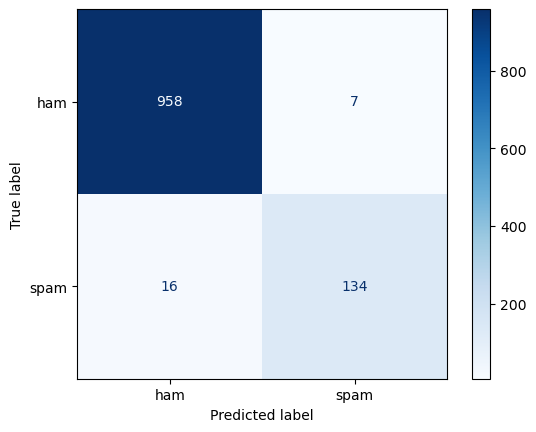

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix,ConfusionMatrixDisplay
accuracy = accuracy_score(y_trues, y_preds)*100
precision = precision_score(y_trues, y_preds)*100
recall = recall_score(y_trues, y_preds)*100
f1 = f1_score(y_trues, y_preds)*100
print(f'Accuracy: {accuracy:.2f}%')
print(f'Precision: {precision:.2f}%')
print(f'Recall: {recall:.2f}%')
print(f'F1 Score: {f1:.2f}%')

cm = confusion_matrix(y_trues, y_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()